# The objective of this code is to generate neuronal networks where neurons don't have a probability 1 to connect within a given radius but have a probability p. 
### Also if possibly not uniformly distributed

# Nothing done yet in this notebook, only a copy from P1

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### 2. Setting up the network

### Random network in a 1x1 square

Original number of nodes: 10000
Original number of edges: 15267
Giant component nodes: 155
Giant component edges: 292
GC fraction: 0.0155


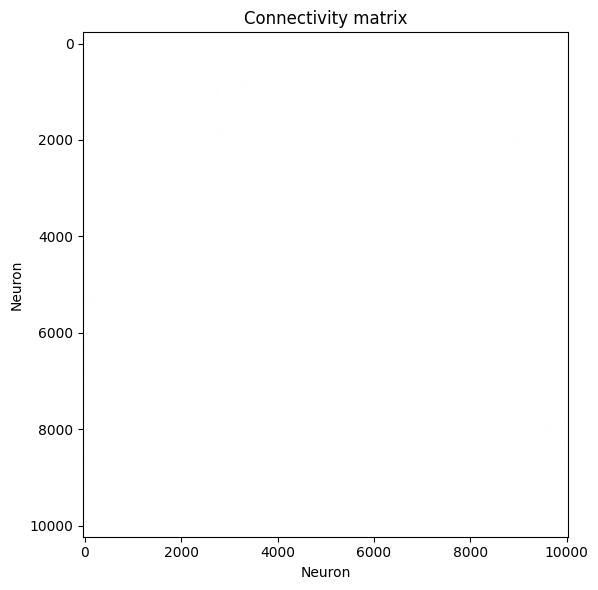

In [2]:
# setting up the graph

NT = 10000  # Number of total neurons



radius = 0.01

network = nx.random_geometric_graph(NT, radius)  # Random geometric graph with radius 0.1


# =========================
# Original adjacency matrix
# =========================

A = nx.to_numpy_array(network)
np.fill_diagonal(A, 0)

# =========================
# Giant component network
# =========================

giant_nodes = max(nx.connected_components(network), key=len)

B_network = network.subgraph(giant_nodes).copy()

# Relabel nodes from 0 to N_gc-1
B_network = nx.convert_node_labels_to_integers(B_network)

# Adjacency matrix of the giant component
B = nx.to_numpy_array(B_network)
np.fill_diagonal(B, 0)

print("Original number of nodes:", network.number_of_nodes())
print("Original number of edges:", network.number_of_edges())
print("Giant component nodes:", B_network.number_of_nodes())
print("Giant component edges:", B_network.number_of_edges())
print("GC fraction:", B_network.number_of_nodes() / NT)



# =========================
# Connectivity matrix
# =========================

NT = B.shape[0]  # Number of neurons in the giant component
Ne = int(NT*0.8)  # N of excitatory neurons
Ni = NT - Ne  # N of inhibitory neurons



MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
    -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
])

S = B * W

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="binary", origin="upper")
plt.xlabel("Neuron")
plt.ylabel("Neuron")
plt.title("Connectivity matrix")
plt.axis("equal")
plt.tight_layout()
plt.show()

### Random network in a LxL square

Original number of nodes: 5000
Original number of edges: 34535
Giant component nodes: 5000
Giant component edges: 34535
GC fraction: 1.0


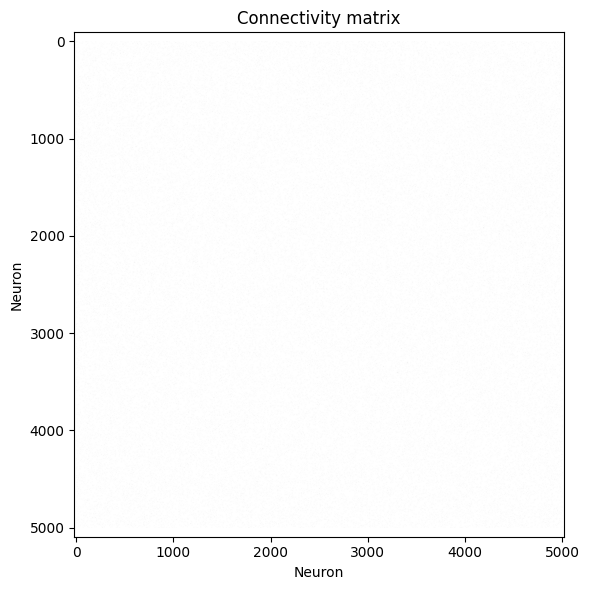

In [3]:
# setting up the graph

NT = 5000  # Number of total neurons

radius = 0.3

L = 10

# Positions in [0, L] x [0, L]
pos = {
    i: L * np.random.rand(2)
    for i in range(NT)
}


network = nx.random_geometric_graph(NT, radius, pos=pos)  # Random geometric graph with radius 0.1


# =========================
# Original adjacency matrix
# =========================

A = nx.to_numpy_array(network)
np.fill_diagonal(A, 0)

# =========================
# Giant component network
# =========================

giant_nodes = max(nx.connected_components(network), key=len)

B_network = network.subgraph(giant_nodes).copy()

# Relabel nodes from 0 to N_gc-1
B_network = nx.convert_node_labels_to_integers(B_network)

# Adjacency matrix of the giant component
B = nx.to_numpy_array(B_network)
np.fill_diagonal(B, 0)

print("Original number of nodes:", network.number_of_nodes())
print("Original number of edges:", network.number_of_edges())
print("Giant component nodes:", B_network.number_of_nodes())
print("Giant component edges:", B_network.number_of_edges())
print("GC fraction:", B_network.number_of_nodes() / NT)



# =========================
# Connectivity matrix
# =========================

NT = B.shape[0]  # Number of neurons in the giant component
Ne = int(NT*0.8)  # N of excitatory neurons
Ni = NT - Ne  # N of inhibitory neurons



MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
    -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
])

S = B * W

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="binary", origin="upper")
plt.xlabel("Neuron")
plt.ylabel("Neuron")
plt.title("Connectivity matrix")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [4]:

# MAX_EXC_WEIGHT = 15
# MAX_INH_WEIGHT = 0.5

# W = np.hstack([
#     MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
#     -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
# ])

# S = B * W


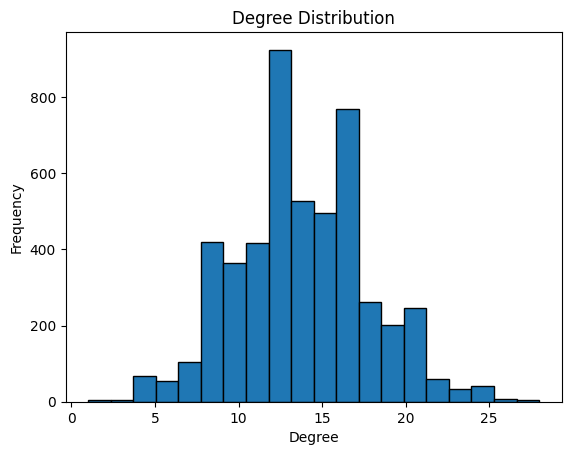

In [5]:
# Plot the degree distribution of the giant component network
degrees = [degree for node, degree in B_network.degree()]
plt.hist(degrees, bins=20, edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")
plt.show()

# Network distribution

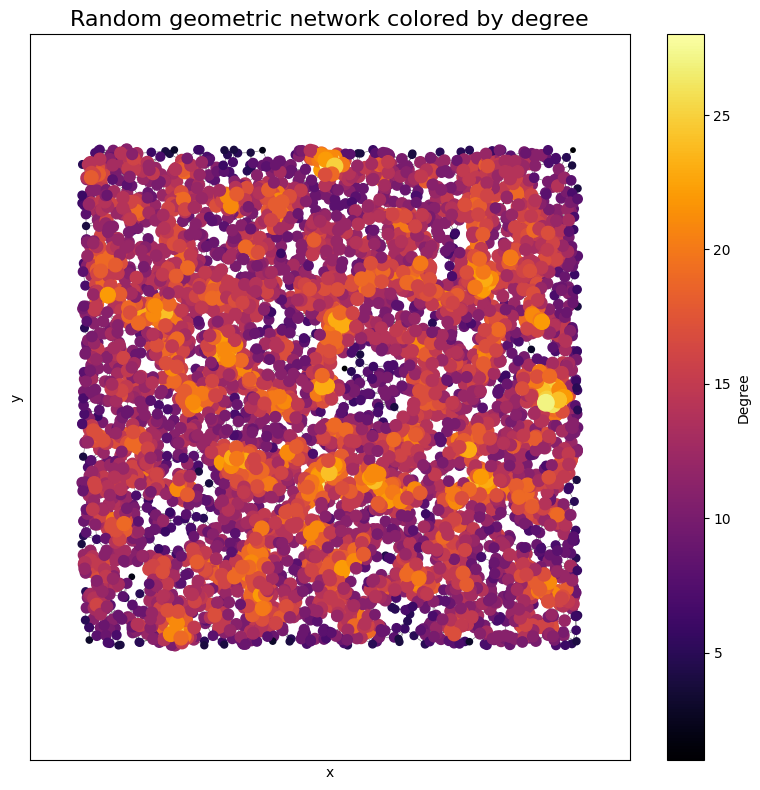

In [6]:
pos = nx.get_node_attributes(network, "pos")

degrees = dict(network.degree())
degree_values = np.array([degrees[i] for i in network.nodes()])

node_sizes = 5 + 5 * degree_values

plt.figure(figsize=(8, 8))

nx.draw_networkx_edges(
    network,
    pos,
    edge_color="black",
    alpha=0.6,
    width=0.4
)

nodes = nx.draw_networkx_nodes(
    network,
    pos,
    node_size=node_sizes,
    node_color=degree_values,
    cmap="inferno",
    alpha=1
)

plt.colorbar(nodes, label="Degree")

plt.title("Random geometric network colored by degree", fontsize=16)
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

## 3. Base matrix to check tests

In [7]:

# ## Connectivity matrix

# frac_delete = 0.80

# A = np.random.rand(N, N)
# A[A < frac_delete] = 0
# A[A > 0] = 1

# # No self-connections
# np.fill_diagonal(A, 0)


# # =========================
# # Synaptic weights
# # =========================

# MAX_EXC_WEIGHT = 4.2
# MAX_INH_WEIGHT = 0.5

# W = np.hstack([
#     MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
#     -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
# ])

# S = A * W

# plt.figure(figsize=(6, 6))
# plt.imshow(A, cmap="binary", origin="upper")
# plt.xlabel("Neuron")
# plt.ylabel("Neuron")
# plt.title("Connectivity matrix")
# plt.axis("equal")
# plt.tight_layout()
# plt.show()

In [8]:

## Simulations

SIM_TIME = 3000

# Reproducibilidad opcional
np.random.seed(42)

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

## 4. Simulating the neurons

In [9]:

# MAX_EXC_WEIGHT = 16
# MAX_INH_WEIGHT = 0.5

# W = np.hstack([
#     MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
#     -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
# ])

# S = B * W

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(NT)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# Plotting 

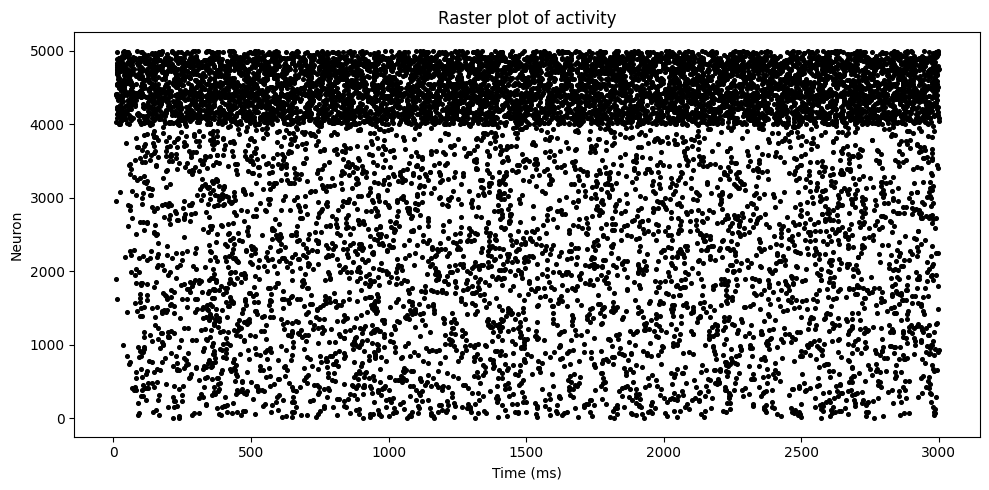

In [10]:
# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()

In [11]:
# =========================
# SYNC measure
# =========================

WINDOW = 20
SIM_TIME_SYNC = 3000

n_windows = SIM_TIME_SYNC // WINDOW
num_active = np.zeros(n_windows)

for j in range(n_windows):
    t_min = WINDOW * j
    t_max = WINDOW * (j + 1)

    mask = (firings[:, 0] > t_min) & (firings[:, 0] <= t_max)
    neurons = firings[mask, 1]

    num_active[j] = len(np.unique(neurons)) / NT

sync = np.max(num_active)

print("Sync =", sync)
print("Active fraction per window:")
print(num_active)

Sync = 0.0204
Active fraction per window:
[0.0074 0.0156 0.0132 0.0114 0.014  0.016  0.0144 0.0186 0.0138 0.0142
 0.0134 0.0186 0.0144 0.0142 0.0152 0.013  0.014  0.02   0.0194 0.0168
 0.0164 0.0188 0.0168 0.0148 0.0156 0.017  0.0128 0.0176 0.0144 0.014
 0.0164 0.0132 0.0186 0.0122 0.0144 0.0186 0.0104 0.0182 0.017  0.0154
 0.0154 0.0138 0.0178 0.0176 0.0168 0.0158 0.015  0.0204 0.0184 0.0164
 0.0168 0.0122 0.0138 0.0148 0.0142 0.0162 0.0166 0.0168 0.0138 0.016
 0.0176 0.0154 0.0164 0.0142 0.0136 0.017  0.0168 0.0162 0.0182 0.018
 0.0184 0.0152 0.0142 0.0178 0.0184 0.014  0.016  0.0136 0.0116 0.0174
 0.011  0.0142 0.0126 0.0146 0.0166 0.0136 0.0148 0.0166 0.018  0.0156
 0.0172 0.0152 0.0148 0.0144 0.0154 0.0154 0.016  0.0136 0.0164 0.0148
 0.012  0.0192 0.0168 0.0176 0.0132 0.0168 0.0188 0.0146 0.016  0.0146
 0.0158 0.0182 0.0184 0.0162 0.0132 0.0148 0.0172 0.0148 0.018  0.0128
 0.0132 0.014  0.0144 0.0168 0.0176 0.014  0.0144 0.0142 0.0176 0.0164
 0.018  0.0164 0.0144 0.0166 0.019  0.

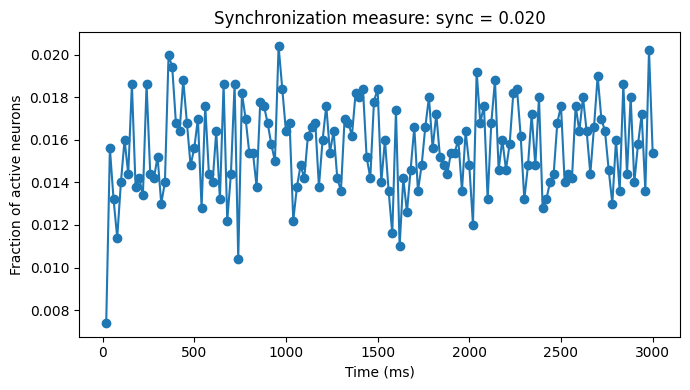

In [12]:
plt.figure(figsize=(7, 4))

times = np.arange(1, n_windows + 1) * WINDOW

plt.plot(times, num_active, marker="o")
plt.xlabel("Time (ms)")
plt.ylabel("Fraction of active neurons")
plt.title(f"Synchronization measure: sync = {sync:.3f}")
plt.tight_layout()
plt.show()